<a href="https://colab.research.google.com/github/richardparik/Projects/blob/master/FINAL%20project/Final_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brain Tumor

Dataset k projektu
https://www.kaggle.com/datasets/denizkavi1/brain-tumor?resource=download

1. 1 Meningioma samples (708 files) = tumor that grows from the membranes that surround the brain and spinal cord,
v naprosté většině případů nezhoubný nádor, který vyrůstá z obalu mozku takzvané tvrdé pleny
2. 2 Glioma samples (1426 files) =a growth of cells that starts in the brain or spinal cord,
typ tumoru, jenž vzniká v mozku nebo míše
3. 3 Pituitary tumor samples (930 files) =tumors that occur in the pituitary gland. Most pituitary tumors are benign, approximately 35% are invasive and just 0.1% to 0.2% are carcinomas



Below is a revised version of your notebook code that incorporates many of the recommended best practices and a clearer overall structure. The key improvements include:

1.Consistent Data Splitting: Creating a train/validation/test split.
2.Data Augmentation: Using ImageDataGenerator (or tf.data pipelines) to augment images and help combat overfitting.
3. Transfer Learning: Demonstrating a transfer learning pipeline using MobileNetV2 (as your original code did).
Callbacks: Adding callbacks such as EarlyStopping and ModelCheckpoint.
Better Organization: Grouping code cells by logic—data exploration, data prep, model building, training, and evaluation.

In [ ]:
pip install keras-tuner

In [ ]:
############################
# 1. IMPORTS & SETUP
############################
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Conv2D, MaxPooling2D, Flatten, Dense,
                                     Dropout, BatchNormalization, GlobalAveragePooling2D)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import VGG16, MobileNetV2
import kagglehub
import keras_tuner as kt
import keras


# Step 1: Dataset Exploration
Download the dataset from Kaggle.
Explore the dataset structure (number of classes, sample images, etc.).
Check for data imbalances and preprocessing needs.


In [ ]:
# Download latest version
dataset_path = kagglehub.dataset_download("denizkavi1/brain-tumor")
label_map = {
    '1': 'Meningioma',
    '2': 'Glioma',
    '3': 'Pituitary'
}

print("Path to dataset files:", dataset_path)

Path to dataset files: /root/.cache/kagglehub/datasets/denizkavi1/brain-tumor/versions/2


## Count Images Per Category

In [ ]:
# Quick check: how many images per category?
for category in sorted(os.listdir(dataset_path)):
    category_path = os.path.join(dataset_path, category)
    if os.path.isdir(category_path):
        print(f"{label_map.get(category, category)}: {len(os.listdir(category_path))} images")

Meningioma: 708 images
Glioma: 1426 images
Pituitary: 930 images


## Display Sample Images

In [ ]:
def show_sample_images(root_path, num_samples=5):
    """
    Displays a few sample images from each class in grayscale or color as needed.
    """
    categories = sorted(os.listdir(root_path))
    # Filter out files vs. directories if needed:
    categories = [cat for cat in categories if os.path.isdir(os.path.join(root_path, cat))]

    fig, axes = plt.subplots(len(categories), num_samples, figsize=(15, 10))
    for i, category in enumerate(categories):
        category_path = os.path.join(root_path, category)
        images = random.sample(os.listdir(category_path), num_samples)

        for j, img_name in enumerate(images):
            img_path = os.path.join(category_path, img_name)
            # For MobileNetV2, we generally want 3-channel images
            # We'll read it in color:
            img = cv2.imread(img_path, cv2.IMREAD_COLOR)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))  # just for display
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_title(f"{label_map.get(category, category)}")

    plt.tight_layout()
    plt.show()

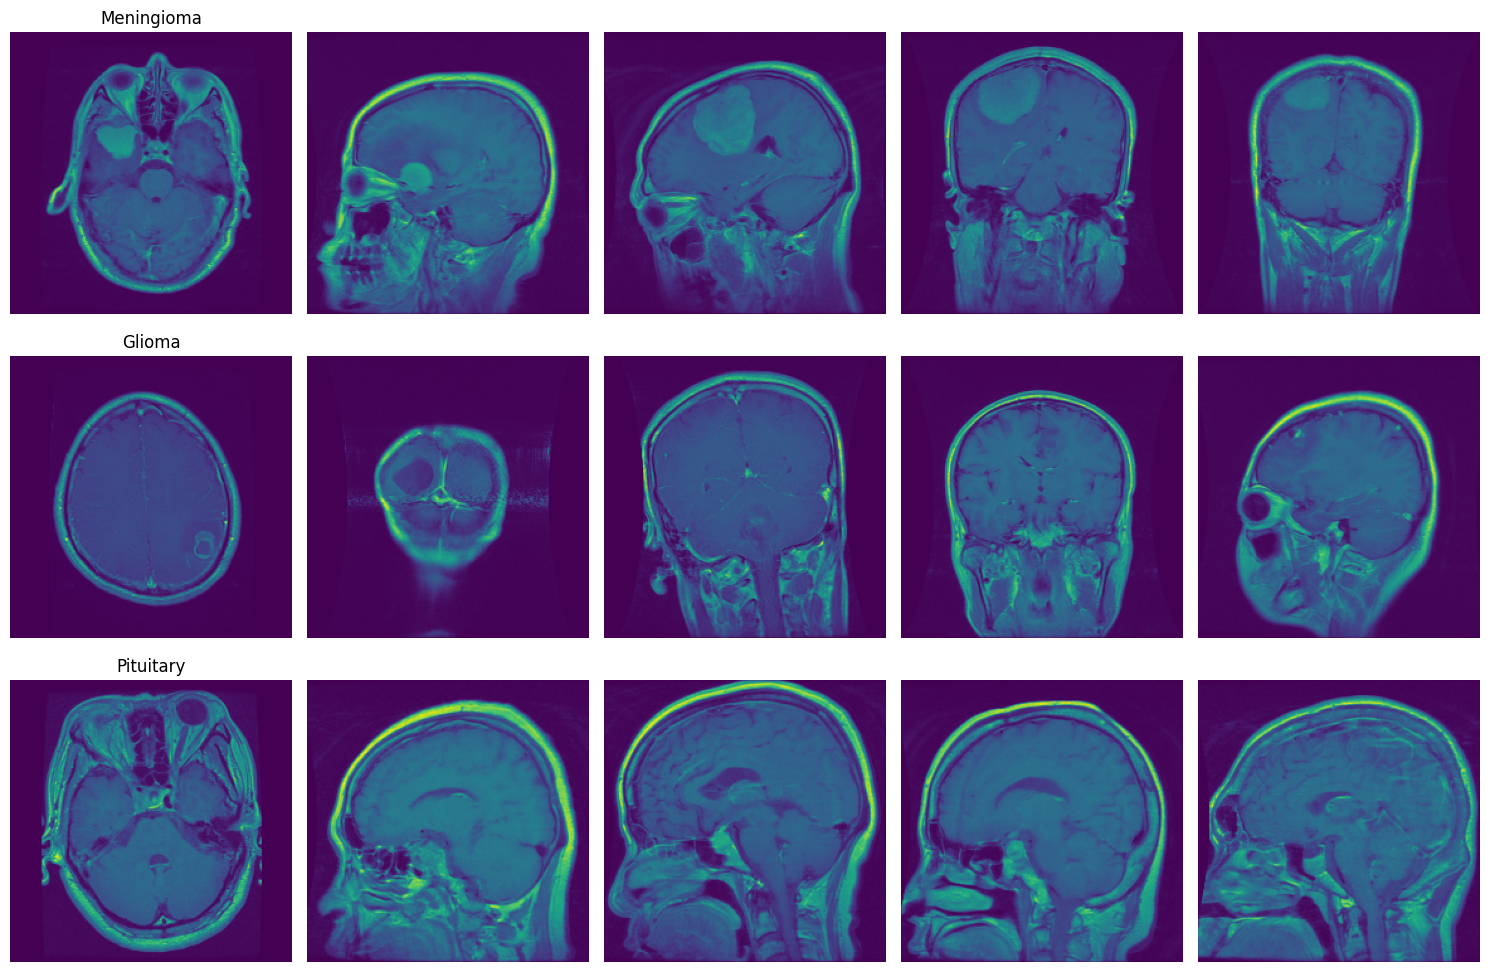

In [ ]:
# Display a few sample images
show_sample_images(dataset_path, num_samples=5)

# Step 2: train-val-test split

✅ Creates the main dataset folder (brain_tumor_split).
✅ Creates three subdirectories (train/, val/, test/).
✅ Creates category folders inside each split.

In [ ]:
# automatically creates a new directory structure to split your dataset into train, validation, and test sets (70/15/15 ratio).
import shutil #used for moving/copying files to different folders.
import pathlib #useful for working with paths in a system-independent way.

# We'll create a new folder 'brain_tumor_split' to hold the splitted subfolders
base_split_dir = 'brain_tumor_split' #main directory where all split data will be stored.
if not os.path.exists(base_split_dir):
    os.makedirs(base_split_dir) #Creates this folder if it doesn't exist already.

for split in ['train', 'val', 'test']: #Loops through ['train', 'val', 'test'] to create three subfolders inside brain_tumor_split/.
    split_dir = os.path.join(base_split_dir, split)
    if not os.path.exists(split_dir):
        os.makedirs(split_dir)
        # also create subdirs for each class
        for cat_key in label_map.keys():
            os.makedirs(os.path.join(split_dir, cat_key))


In [ ]:
"""
brain_tumor_split/
    ├── train/
    │   ├── 1/  (Meningioma images)
    │   ├── 2/  (Glioma images)
    │   ├── 3/  (Pituitary images)
    │
    ├── val/
    │   ├── 1/
    │   ├── 2/
    │   ├── 3/
    │
    ├── test/
        ├── 1/
        ├── 2/
        ├── 3/
"""

This function splits images into training, validation, and test sets using a 70/15/15 ratio (or any custom ratio). It then copies images into their respective folders.

In [ ]:
# Function to split the images
def split_data(original_dir, split_dir, split_ratio=(0.7, 0.15, 0.15)):
#folder containing images of one tumor class
#base folder where train, val, and test directories exist
#The percentage of data split (default = 70% train, 15% val, 15% test).
    """
    split_ratio: (train, val, test)
    """
    images = os.listdir(original_dir)
    images = [img for img in images if img.lower().endswith(('.png', '.jpg', '.jpeg'))] #Filters out only valid image files (.png, .jpg, .jpeg).
    random.shuffle(images) #Shuffles the list of images to ensure a random distribution.

    # Computes how many images go into train/val/test folders based on the ratio.
    n_total = len(images)
    n_train = int(split_ratio[0] * n_total)  # 70% for training
    n_val   = int(split_ratio[1] * n_total)  # 15% for validation
    n_test  = n_total - n_train - n_val  # Remaining 15% for testing

    train_files = images[:n_train] #training set
    val_files   = images[n_train:n_train+n_val] # validation set
    test_files  = images[n_train+n_val:] # test set

    # Copy files into the respective folders ("brain_tumor_split/train/{category}/" etc.)
    # shutil.copy() ensures that the original dataset is untouched, and a copy is placed in the correct split folder.
    for f in train_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'train', os.path.basename(original_dir), f))
    for f in val_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'val', os.path.basename(original_dir), f))
    for f in test_files:
        shutil.copy(os.path.join(original_dir, f),
                    os.path.join(split_dir, 'test', os.path.basename(original_dir), f))

# Apply split to each category folder, Loops through each class category (1, 2, 3).
for category in label_map.keys():
    cat_folder = os.path.join(dataset_path, category)
    if os.path.isdir(cat_folder):
        split_data(cat_folder, base_split_dir) # for each category to distribute images correctly.


# Step 3: Data augmentation

Tip1: Pohrát si s augmentation (rotování? atd?), Use data augmentation to introduce variations during training.
Tip2: If you want to push accuracy higher, try:

* Fine-tuning MobileNetV2 layers.
* Training for more epochs.
* Increasing dropout or adding L2 regularization.
* Checking for class imbalance in test data.

tip3: Test Loss (0.3001) is Higher than Validation Loss (0.2498)
* Increase dropout (e.g., Dropout(0.4) instead of Dropout(0.3)).
* Try adding L2 weight decay regularization in your dense layer
* Check class distribution in your test set to make sure it's balanced.

In [ ]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,#rescales images automatically based on the pretrained model you are using, is a built-in function from TensorFlow/Keras applications.
    rotation_range=15, # Randomly rotates the image by up to ±15 degrees.
    width_shift_range=0.1, #Moves images left/right by up to 10% of the width.
    height_shift_range=0.1, #Moves images up/down by up to 10% of the height.
    horizontal_flip=True, #Flips images horizontally (left-right).
    fill_mode='nearest' #Fills missing pixels with nearest pixel values (best for medical images).
)
#The validation set is used to monitor performance during training.
#The test set is used after training to check final accuracy.
val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input) #No augmentation for validation & test sets.,Only applies preprocess_input (normalization).
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_dir = os.path.join(base_split_dir, 'train') #Defines paths to training, validation, and test datasets.
val_dir   = os.path.join(base_split_dir, 'val') #These folders contain MRI images sorted by class (from previous splitting steps).
test_dir  = os.path.join(base_split_dir, 'test')

In [ ]:
batch_size = 32
img_size = (224, 224)

train_generator = train_datagen.flow_from_directory(
    directory=train_dir,
    target_size=img_size,
    color_mode='rgb',  # MobileNet expects 3-channel
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    directory=val_dir,
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    directory=test_dir,
    target_size=img_size,
    color_mode='rgb',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 3037 images belonging to 3 classes.
Found 1459 images belonging to 3 classes.
Found 1476 images belonging to 3 classes.


In [ ]:
#data augmentation - další typy
"""
    rescale=1./255, # Normalize pixel values (always keep this)
    rotation_range=20, # Slightly higher rotation (more variation)
    width_shift_range=0.2, # Increased shift to 20% of width
    height_shift_range=0.2, # Increased shift to 20% of height

    horizontal_flip=True, #není kontraproduktivní?
    vertical_flip=True,  # Some MRI datasets benefit from vertical flips,

    # Zoom & Scaling
    zoom_range=0.2,  #Allows zooming in/out to improve generalization, je potřeba?
    shear_range=0.15,  #New: Helps the model become invariant to distortions

    # Brightness Adjustments (for contrast variation)
    brightness_range=[0.8, 1.2],  # 🔹 New: Varies brightness by ±20% (helps with contrast differences)

    fill_mode='nearest' # Keeps edges natural during transformations

"""



Found 2977 images belonging to 3 classes.
Found 1180 images belonging to 3 classes.
Found 1208 images belonging to 3 classes.


# Step 4: Model building

## ResNet, VGG16, VGG19

In [ ]:
# Use VGG16 as a feature extractor
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

# Add a custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Converts feature maps to a vector
x = Dense(512, activation='relu')(x)  # Fully connected layer
x = Dropout(0.3)(x)  # Prevent overfitting
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary)

# Define final model
model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Print model summary
model.summary()

Adam optimizer + MobileNetV2

In [ ]:
# Use MobileNetV2 as a feature extractor
# Setting `include_top=False` means we remove the default classifier to add our own
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

# Add a custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.3)(x)
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary)

model = Model(inputs=base_model.input, outputs=output_layer)

# Compile model
model.compile(optimizer=Adam(learning_rate=1e-3),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_7[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,395 (11.12 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

SGD with momentum

In [ ]:
# Setting `include_top=False` means we remove the default classifier to add our own
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False  # Freeze base layers initially

# Add a custom classifier on top
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.25)(x)
output_layer = Dense(3, activation='softmax')(x)  # 3 classes (Meningioma/Glioma/Pituitary)

model = Model(inputs=base_model.input, outputs=output_layer)

# Use SGD with Momentum
sgd = SGD(learning_rate=0.01, momentum=0.9, nesterov=True)  # Nesterov=True can improve convergence

# Compile model with SGD
model.compile(optimizer=sgd,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8             │ (None, 224, 224, 3)    │              0 │ -                      │
│ (InputLayer)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1 (Conv2D)            │ (None, 112, 112, 32)   │            864 │ input_layer_8[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ bn_Conv1                  │ (None, 112, 112, 32)   │            128 │ Conv1[0][0]            │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Conv1_relu (ReLU)         │ (None, 112, 112, 32)   │              0 │ bn_Conv1[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise   │ (None, 112, 112, 32)   │            288 │ Conv1_relu[0][0]       │
│ (DepthwiseConv2D)         │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │            128 │ expanded_conv_depthwi… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_depthwise_… │ (None, 112, 112, 32)   │              0 │ expanded_conv_depthwi… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project     │ (None, 112, 112, 16)   │            512 │ expanded_conv_depthwi… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ expanded_conv_project_BN  │ (None, 112, 112, 16)   │             64 │ expanded_conv_project… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand (Conv2D)   │ (None, 112, 112, 96)   │          1,536 │ expanded_conv_project… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_BN         │ (None, 112, 112, 96)   │            384 │ block_1_expand[0][0]   │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_expand_relu       │ (None, 112, 112, 96)   │              0 │ block_1_expand_BN[0][… │
│ (ReLU)                    │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_pad               │ (None, 113, 113, 96)   │              0 │ block_1_expand_relu[0… │
│ (ZeroPadding2D)           │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ block_1_depthwise         │ (None, 56, 56, 96)     │            864 │ block_1_pad[0][0]      │
│ (DepthwiseConv2D)         │                        │                │                        │
├──────────────────────

 Total params: 2,915,395 (11.12 MB)

 Trainable params: 657,411 (2.51 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

# Step 5: Training

tip: Training Accuracy (81%) is Lower than Validation/Test (88%)
* Train for more epochs: Try increasing patience=10 in EarlyStopping to allow more training.
* Unfreeze some MobileNetV2 layers: Since you are using transfer learning, you can try fine-tuning the deeper layers of MobileNetV2 after initial training:

In [ ]:
#Adam optimizer + MobileNetV2

In [ ]:
#náhradní krok, projetí všech 20 epoch bez EarlyStopping
ckpt_path = 'best_model.keras'
model_ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True) #If the validation loss does NOT improve, it does NOT overwrite the last best model.

epochs = 20

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[model_ckpt]
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 100s 944ms/step - accuracy: 0.6420 - loss: 0.9290 - val_accuracy: 0.8684 - val_loss: 0.3532
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 841ms/step - accuracy: 0.8444 - loss: 0.3773 - val_accuracy: 0.8849 - val_loss: 0.2962
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 79s 832ms/step - accuracy: 0.8786 - loss: 0.3016 - val_accuracy: 0.8807 - val_loss: 0.2856
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 854ms/step - accuracy: 0.8834 - loss: 0.2869 - val_accuracy: 0.8547 - val_loss: 0.3489
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 872ms/step - accuracy: 0.8817 - loss: 0.2810 - val_accuracy: 0.9212 - val_loss: 0.2140
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 848ms/step - accuracy: 0.8860 - loss: 0.2722 - val_accuracy: 0.8944 - val_loss: 0.2571
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 80s 846ms/step - accuracy: 0.9025 - loss: 0.2425 - val_accuracy: 0.8965 - val_loss: 0.2447
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 878ms/step - accuracy: 0.9025 - loss: 0.2412 - val_acc

## Early stop

In [ ]:
# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
ckpt_path = 'best_model.keras'
model_ckpt = ModelCheckpoint(ckpt_path, monitor='val_loss', save_best_only=True)

epochs = 20

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=val_generator,
    callbacks=[early_stop, model_ckpt]
)

Epoch 1/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 96s 922ms/step - accuracy: 0.7052 - loss: 0.6791 - val_accuracy: 0.8492 - val_loss: 0.3664
Epoch 2/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 893ms/step - accuracy: 0.8484 - loss: 0.3636 - val_accuracy: 0.8602 - val_loss: 0.3572
Epoch 3/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 873ms/step - accuracy: 0.8595 - loss: 0.3591 - val_accuracy: 0.8849 - val_loss: 0.2989
Epoch 4/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 856ms/step - accuracy: 0.8845 - loss: 0.2870 - val_accuracy: 0.8588 - val_loss: 0.3266
Epoch 5/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 81s 860ms/step - accuracy: 0.8867 - loss: 0.2902 - val_accuracy: 0.8828 - val_loss: 0.2852
Epoch 6/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 85s 899ms/step - accuracy: 0.8935 - loss: 0.2667 - val_accuracy: 0.8670 - val_loss: 0.3201
Epoch 7/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 868ms/step - accuracy: 0.8881 - loss: 0.2623 - val_accuracy: 0.8341 - val_loss: 0.4707
Epoch 8/20
95/95 ━━━━━━━━━━━━━━━━━━━━ 83s 872ms/step - accuracy: 0.8948 - loss: 0.2509 - val_accu

## Fine Tuning

# Step 6: Evaluation

In [ ]:
# Load the best weights
model.load_weights(ckpt_path)

# Evaluate on validation set
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation Loss: {val_loss:.4f}")
print(f"Validation Accuracy: {val_acc:.4f}")

46/46 ━━━━━━━━━━━━━━━━━━━━ 17s 362ms/step - accuracy: 0.8607 - loss: 0.3271
Validation Loss: 0.1753
Validation Accuracy: 0.9301


In [ ]:
# Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

47/47 ━━━━━━━━━━━━━━━━━━━━ 19s 402ms/step - accuracy: 0.8633 - loss: 0.3176
Test Loss: 0.1645
Test Accuracy: 0.9350


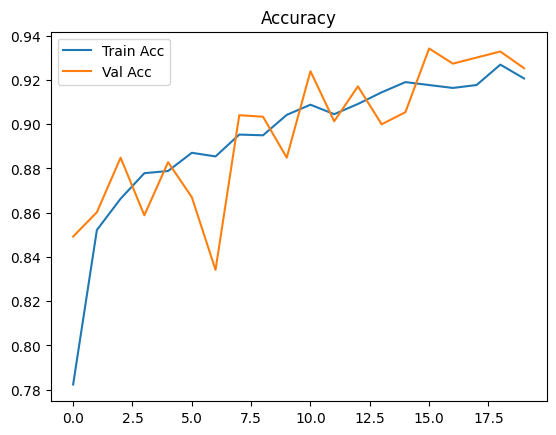

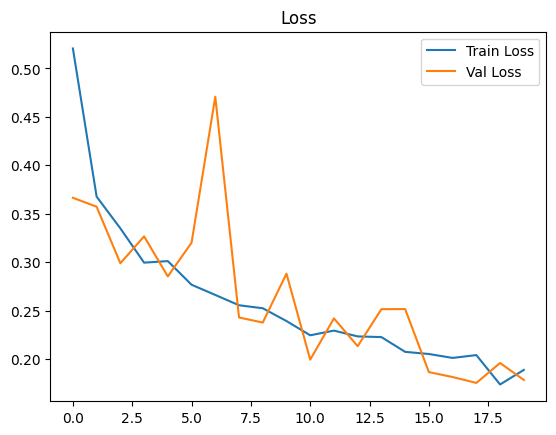

In [ ]:
# Plot training curves
plt.figure()
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()
plt.show()

In [ ]:
"""
Observations
1️⃣ Validation Loss is Highly Unstable
There are spikes in the validation loss (e.g., around epoch 5 and 10).
This suggests that the model is not generalizing well and is sensitive to batch variations.

2️⃣Training Loss Decreases Smoothly
The training loss decreases in a smooth curve, which is expected.
This means that the model is learning well on the training data.

3️⃣ Validation Loss is Higher than Training Loss at Some Points
This is normal, but extreme differences can indicate overfitting or bad batch selection.
"""

In [ ]:
"""
✅ Lower learning rate (1e-4 or 1e-5).
✅ Ensure validation set is diverse.
✅ Add L2 regularization & dropout.
✅ Increase batch size if needed.
✅ Check augmentations (train vs. val).
"""

# Step 7: Save/load model

In [ ]:
# Save the final model in Keras format
model.save("brain_tumor_model_final.keras")
print("Model saved as brain_tumor_model_final.keras.")

Model saved as brain_tumor_model_final.keras.


# Zmeny oproti v1

## Key Changes & Rationale


1. Train/Validation/Test Split
Instead of training on all images directly, it’s good practice to create a clear split, ensuring robust evaluation.
2. Data Augmentation
Medical imaging datasets are often small. Augmentation (rotation, shifts, flips) can significantly improve generalization.
3. MobileNetV2
We use include_top=False to remove the default classifier, then freeze its weights, and add our own classification head.
Use preprocess_input specifically for MobileNet.
4. Callbacks
EarlyStopping: Halts training when validation loss stops improving.
ModelCheckpoint: Automatically saves the best weights during training.
5. Evaluation
We explicitly evaluate on both the validation set and a final test set to measure out-of-sample performance.
We also plot training/validation curves.

Feel free to adjust hyperparameters (e.g., IMG_SIZE, batch_size, learning_rate, or data augmentation settings) and experiment with unfreezing deeper MobileNetV2 layers after the initial fine-tuning if you want potentially higher accuracy (at the expense of more training time and risk of overfitting).

This organized approach should give you a solid baseline classification model on the brain tumor dataset—while using best practices for medical imaging tasks with modest data sizes. ​